In [1]:
!python -m pip install tensorflow

In [2]:
# Import libraries and classes that will be used
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

## Dataset Description
The dataset used for this project is the CIFAR 10 dataset. It contains small color images that belong to 10 different classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck. Each image is 32 x 32 pixels and has 3 color channels. 
The dataset has 50,000 training images and 10,000 testing images. Since each image belongs to one class, this is a supervised multi-class classification problem.
This dataset is a good fit for convolutionl neaural network because CNNs are designed to work well with image data. The model will try to learn visual patterns from the images and use those patterns to predict the correct class label.

## Problem Definition
The goal of this project is to build a convolutional neural network that can classify CIFAR 10 images into their correct object categories. The input data will be the image pixel values, and the output will be one of the 10 possible class labels. I expect the CNN model to perform reasonably well because convolutional layers are useful for finding visual patterns in images. However, I also expect the model to confuse some classes because certain objects may look visually similar, such as cats and dogs or automobiles and trucks.

In [3]:
# Import dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [4]:
# Look at the shape of the training and testing data
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [5]:
# Create class names for the CIFAR 10 dataset
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [6]:
# look at the first few target labels
print(y_train[:10])

[[6]
 [9]
 [9]
 [4]
 [1]
 [1]
 [2]
 [7]
 [8]
 [3]]


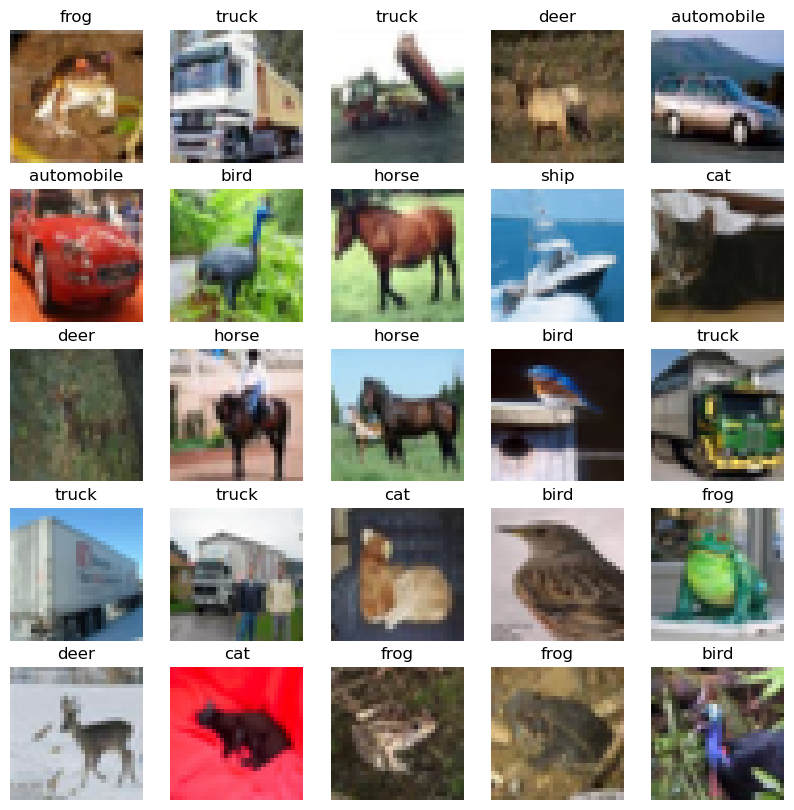

In [7]:
# Look at some sample images from the dataset
plt.figure(figsize = (10,10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

In [8]:
# Normalize the pixel values. Dividing by 255 scales them to between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0

In [9]:
# Convert target labels to categorical form
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [10]:
# Look at the original label and the categorical version
print("Original label:", y_train[0])
print("Categorical label:", y_train_cat[0])

Original label: [6]
Categorical label: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


## Data Processing
The image pixel values were normalized by dividing each value by 225. This changed the pixel values from the original range of 0 to 255 into a range from 0 to 1. This helps the neural network train more effectively because the input values are smaller and more consistent.
The target labels were also converted into categorical form because of the type of classification problem. It has 10 possible classes.

## CNN Model 1

In [11]:
cnn_model_1 = Sequential()

#Input layer 
cnn_model_1.add(Input(shape = (32, 32, 3)))

# First convolution and pooling layers
cnn_model_1.add(Conv2D(32, (3, 3), activation = "relu",))
cnn_model_1.add(MaxPooling2D((2, 2)))

#Second convolution and pooling layers
cnn_model_1.add(Conv2D(64, (3, 3), activation = "relu"))
cnn_model_1.add(MaxPooling2D((2, 2)))

# Flatten the feature maps before passing them into dense layers
cnn_model_1.add(Flatten())

# Dense Layer
cnn_model_1.add(Dense(64, activation = "relu"))

# Output layer
cnn_model_1.add(Dense(10, activation = "softmax"))

# Compile the 1st CNN model
cnn_model_1.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)        

# look at the structure of the model
cnn_model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

## CNN Model 1 Description

The first CNN model was built as a basic convolutional neural network for image classification. It uses 2 convolutional layers, 2 pooling layers, a flatten layer, 1 dense hidden layer, and 1 output layer.

The convolutional layers are used to detect visual patterns in the images. These patterns may include edges, shapes, colors, or textures that help the model tell the classes apart. The pooling layers reduce the size of the feature maps, which makes the model more efficient while still keeping important information.

After the convolution and pooling layers, the flatten layer converts the feature maps into one long vector. This allows the information to be passed into the dense layer. The final output layer has 10 neurons because there are 10 possible CIFAR 10 classes. The softmax activation function is used in the output layer because this is a multi class classification problem.

In [12]:
# Train 1st CNN model
history = cnn_model_1.fit(
    X_train,
    y_train_cat,
    epochs = 10,
    batch_size = 64,
    validation_split = 0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.4202 - loss: 1.5971 - val_accuracy: 0.4990 - val_loss: 1.4167
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.5601 - loss: 1.2459 - val_accuracy: 0.5700 - val_loss: 1.2184
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.6132 - loss: 1.1069 - val_accuracy: 0.6222 - val_loss: 1.0950
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.6499 - loss: 1.0044 - val_accuracy: 0.6334 - val_loss: 1.0545
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.6748 - loss: 0.9402 - val_accuracy: 0.6650 - val_loss: 0.9793
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.6970 - loss: 0.8775 - val_accuracy: 0.6611 - val_loss: 1.0107
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.7114 - loss: 0.8352 - val_accuracy: 0.6674 - val_loss: 0.9672
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.7278 - loss: 0.7856 - 

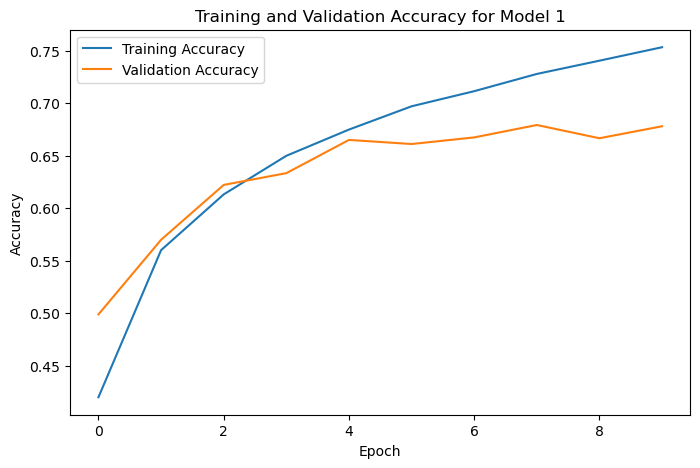

In [13]:
# Plot training and validation accuracy for Model 1
plt.figure(figsize = (8,5))

plt.plot(history.history["accuracy"], label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy for Model 1")
plt.legend()
plt.show()

## Training and Validation Accuracy for CNN Model 1

The graph shows that CNN Model 1 improved over the 10 training epochs. The training accuracy increased from about 43% to about 75%, which shows that the model was learning from the training images.

The validation accuracy also improved at first, increasing from about 51% to around 68%. However, near the later epochs, the validation accuracy stopped improving and slightly decreased while the training accuracy continued to rise. This suggests that CNN Model 1 may have started to overfit the training data.

The graph shows that Model 1 was able to learn useful visual patterns from the CIFAR 10 images, but the gap between training accuracy and validation accuracy near the end suggests that the model performed better on the data it trained on than on validation data.

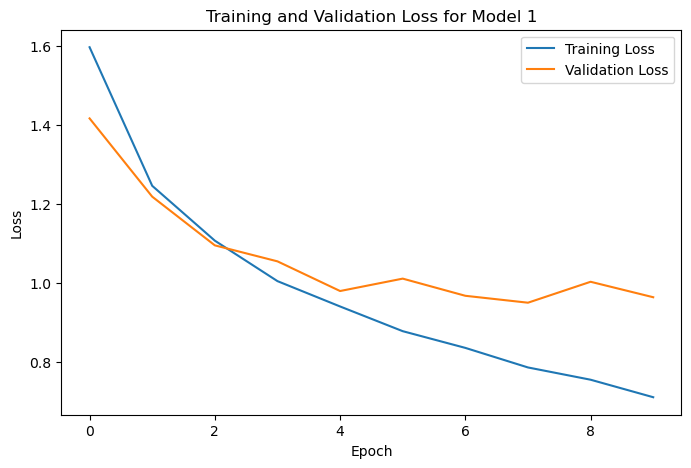

In [14]:
# Plot training and validation loss for Model 1
plt.figure(figsize = (8, 5))

plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss for Model 1")
plt.legend()
plt.show()

## Training and Validation Loss for CNN Model 1

The graph shows that the training loss decreased steadily over the 10 epochs. This means the model was making fewer errors on the training data as it learned.

The validation loss also decreased at first, but it started to level off near the later epochs and slightly increased at the end. This supports the same idea shown in the accuracy graph: CNN Model 1 learned the training data well, but it may have started to overfit because the validation performance stopped improving while the training performance continued to improve.

In [15]:
# Evaluate the 1st model on the test set
test_loss_1, test_accuracy_1 = cnn_model_1.evaluate(X_test, y_test_cat)

print(f"Model 1 Test Loss: {test_loss_1:.4f}")
print(f"Model 1 Test Accuracy: {test_accuracy_1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6814 - loss: 0.9686
Model 1 Test Loss: 0.9686
Model 1 Test Accuracy: 0.6814


In [16]:
# Predict on test set
y_pred_prob = cnn_model_1.predict(X_test)

# Convert predicted probabilities into class labels
y_pred = np.argmax(y_pred_prob, axis = 1)

# Convert y_test into a one dimensional array
y_test_labels = y_test.flatten()

# Evaluate model performance using classification report
print(classification_report(y_test_labels, y_pred, target_names = class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
              precision    recall  f1-score   support

    airplane       0.71      0.73      0.72      1000
  automobile       0.89      0.72      0.79      1000
        bird       0.54      0.62      0.58      1000
         cat       0.55      0.47      0.50      1000
        deer       0.62      0.63      0.63      1000
         dog       0.63      0.53      0.58      1000
        frog       0.84      0.66      0.74      1000
       horse       0.65      0.81      0.72      1000
        ship       0.73      0.85      0.78      1000
       truck       0.72      0.81      0.76      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000



## CNN Model 1 Test Results

CNN Model 1 achieved a test accuracy of about 67.8% and a test loss of about 0.9678. This means the model correctly classified a little over two thirds of the test images.

The classification report shows that the model performed better on some classes than others. The strongest results were for classes like ship, frog, automobile, truck and horse. For example, the model had strong recall for truck, meaning it correctly identified many of the actual truck images.

The model struggled more with classes like cat, bird, and dog. This makes sense because these animal classes can look visually similar in small 32 by 32 images. Overall, CNN Model 1 performed reasonably well for a basic CNN, but the results show that some CIFAR 10 classes are harder to separate than others.

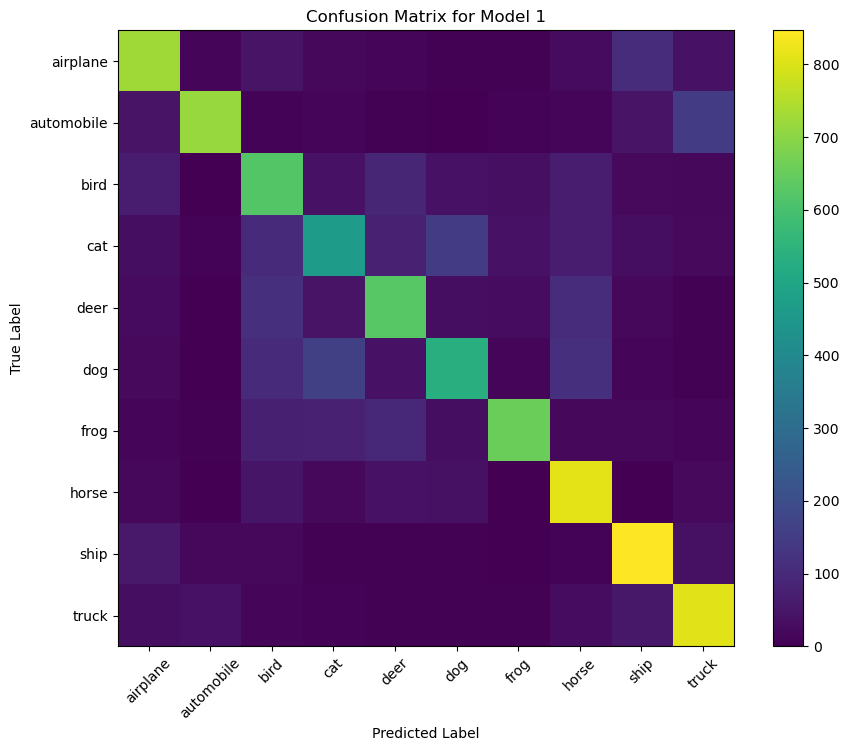

In [18]:
# Create confusion matrix
cm_1 = confusion_matrix(y_test_labels, y_pred)

plt.figure(figsize = (10, 8))
plt.imshow(cm_1)
plt.title("Confusion Matrix for Model 1")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(10), class_names, rotation = 45)
plt.yticks(range(10), class_names)
plt.colorbar()
plt.show()

## CNN Model 2

In [19]:
cnn_model_2 = Sequential()

#Input layer
cnn_model_2.add(Input(shape = (32, 32, 3)))

#First convolution and pooling layers    
cnn_model_2.add(Conv2D(32, (3, 3), activation = "relu",))
cnn_model_2.add(MaxPooling2D((2, 2)))

# Second convolution and pooling layer
cnn_model_2.add(Conv2D(64, (3, 3), activation = "relu"))
cnn_model_2.add(MaxPooling2D((2, 2)))

# Second convolution layer
cnn_model_2.add(Conv2D(64, (3, 3), activation = "relu"))

# Flatten the feature maps before passing them into dense layers
cnn_model_2.add(Flatten())

# Dense layer
cnn_model_2.add(Dense(64, activation = "relu"))
cnn_model_2.add(Dropout(0.5))

# Output layer
cnn_model_2.add(Dense(10, activation = "softmax"))

# Compile the 2nd CNN model
cnn_model_2.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)        

# look at the structure of the model
cnn_model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

## CNN Model 2 Description

CNN Model 2 was created as an improved version of CNN Model 1. It uses three convolutional layers, two pooling layers, a flatten layer, one dense hidden layer, a dropout layer, and one output layer.

The extra convolutional layer gives the model another chance to learn visual patterns from the CIFAR 10 images before the data is passed into the dense layer. The pooling layers reduce the size of the feature maps, and the flatten layer changes the feature maps into one long vector so the dense layer can use them for classification.

This model also includes a dropout layer after the dense hidden layer. Dropout randomly ignores some neurons during training, which can help reduce overfitting and make the model more generalizable.

CNN Model 2 has 122,570 trainable parameters. This is fewer than CNN Model 1, even though Model 2 has an extra convolutional layer. This happens because the third convolutional layer reduces the feature maps before they reach the dense layer. The purpose of this model is to see whether adding dropout and making the CNN slightly deeper improves performance compared to CNN Model 1.

In [20]:
# Train the 2nd CNN model
history_2 = cnn_model_2.fit(
    X_train,
    y_train_cat,
    epochs = 10,
    batch_size = 64,
    validation_split = 0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.3207 - loss: 1.8233 - val_accuracy: 0.4557 - val_loss: 1.4972
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.4473 - loss: 1.5118 - val_accuracy: 0.5199 - val_loss: 1.3320
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.5021 - loss: 1.3830 - val_accuracy: 0.5593 - val_loss: 1.2323
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.5405 - loss: 1.2954 - val_accuracy: 0.5861 - val_loss: 1.1947
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.5727 - loss: 1.2076 - val_accuracy: 0.6239 - val_loss: 1.0774
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.5986 - loss: 1.1420 - val_accuracy: 0.6329 - val_loss: 1.0365
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.6175 - loss: 1.0905 - val_accuracy: 0.6530 - val_loss: 1.0021
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.6352 - loss: 1.0414 - 

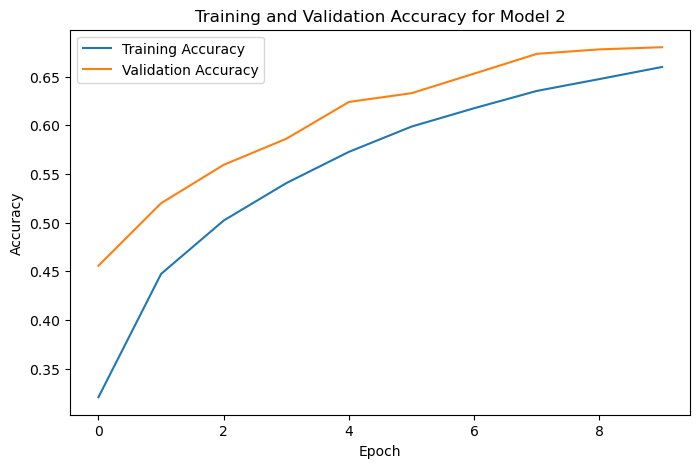

In [21]:
# Plot training and validation accuracy for Model 2
plt.figure(figsize = (8,5))

plt.plot(history_2.history["accuracy"], label = "Training Accuracy")
plt.plot(history_2.history["val_accuracy"], label = "Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy for Model 2")
plt.legend()
plt.show()

## Training and Validation Accuracy for CNN Model 2

CNN Model 2 was trained for 10 epochs using a batch size of 64 and a validation split of 0.2. This means that 80% of the training data was used to train the model, while 20% was used as validation data during training.

The accuracy graph shows that both the training accuracy and validation accuracy increased over the 10 epochs. The training accuracy increased from about 31% to about 66%, while the validation accuracy increased from about 45% to about 68%.

The validation accuracy stayed slightly higher than the training accuracy for most of the training process. This can happen because Model 2 uses dropout, which randomly ignores some neurons during training. Since dropout makes training more difficult, the training accuracy can be lower. During validation, dropout is turned off, so the model uses all of its neurons.

Overall, the graph shows that CNN Model 2 learned steadily and did not show a strong sign of overfitting. The validation accuracy continued to improve through the later epochs instead of dropping.

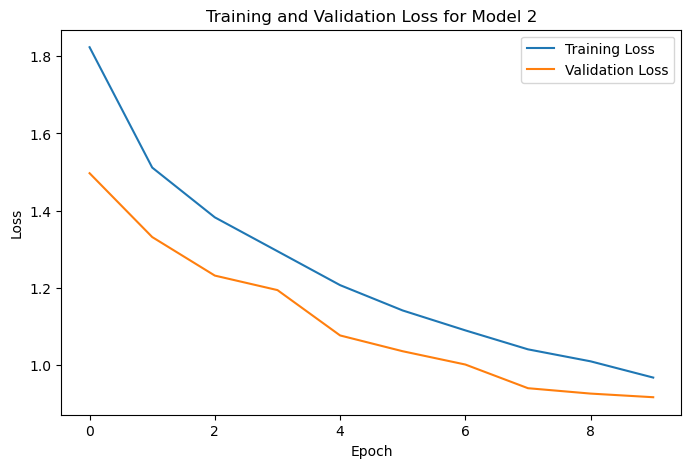

In [22]:
# Plot training and validation loss for Model 2
plt.figure(figsize = (8, 5))

plt.plot(history_2.history["loss"], label = "Training Loss")
plt.plot(history_2.history["val_loss"], label = "Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss for Model 2")
plt.legend()
plt.show()

## Training and Validation Loss for CNN Model 2

The loss graph shows that both the training loss and validation loss decreased over the 10 epochs. This means CNN Model 2 was making fewer errors as training continued.

The training loss decreased from about 1.84 to about 0.97, while the validation loss decreased from about 1.51 to about 0.94. The validation loss stayed slightly lower than the training loss for most of the training process. This makes sense because Model 2 includes dropout, which makes training harder by randomly ignoring some neurons during training. During validation, dropout is turned off.

Overall, the decreasing loss values show that CNN Model 2 learned steadily. Since the validation loss continued to decrease instead of rising near the end, the graph does not show a strong sign of overfitting.

In [23]:
# Evaluate the 2nd model on the test set
test_loss_2, test_accuracy_2 = cnn_model_2.evaluate(X_test, y_test_cat)

print(f"Model 2 Test Loss: {test_loss_2:.4f}")
print(f"Model 2 Test Accuracy: {test_accuracy_2:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6781 - loss: 0.9210
Model 2 Test Loss: 0.9210
Model 2 Test Accuracy: 0.6781


In [24]:
# Predict on test set for CNN Model 2
y_pred_prob_2 = cnn_model_2.predict(X_test)

# Convert predicted probabilities into class labels
y_pred_2 = np.argmax(y_pred_prob_2, axis = 1)

# Convert y_test into a one dimensional array
y_test_labels_2 = y_test.flatten()

# Evaluate model performance using classification report
print(classification_report(y_test_labels_2, y_pred_2, target_names = class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
              precision    recall  f1-score   support

    airplane       0.73      0.72      0.73      1000
  automobile       0.78      0.85      0.81      1000
        bird       0.56      0.56      0.56      1000
         cat       0.44      0.52      0.47      1000
        deer       0.68      0.54      0.60      1000
         dog       0.58      0.56      0.57      1000
        frog       0.73      0.74      0.73      1000
       horse       0.78      0.71      0.74      1000
        ship       0.76      0.83      0.79      1000
       truck       0.80      0.76      0.78      1000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000



## CNN Model 2 Classification Report

CNN Model 2 achieved a test accuracy of about 67.4%. This means the model correctly classified a little over two thirds of the test images.The classification report shows that the model performed better on some classes than others. The strongest results were for automobile, frog, truck, ship, and airplane. For example, automobile had strong precision and recall, meaning the model was usually accurate when predicting automobiles and also found most of the actual automobile images.

The model struggled more with classes like cat, bird, dog, and deer. This is similar to CNN Model 1 and makes sense because these animal classes can look visually similar in small 32 by 32 images. The cat class had the lowest performance, with an f1 score of about 0.46, which shows that the model had difficulty separating cats from other similar classes.

Overall, CNN Model 2 performed at a similar level to CNN Model 1. It did not greatly improve the overall test accuracy, but it still learned useful image patterns from the CIFAR 10 dataset.


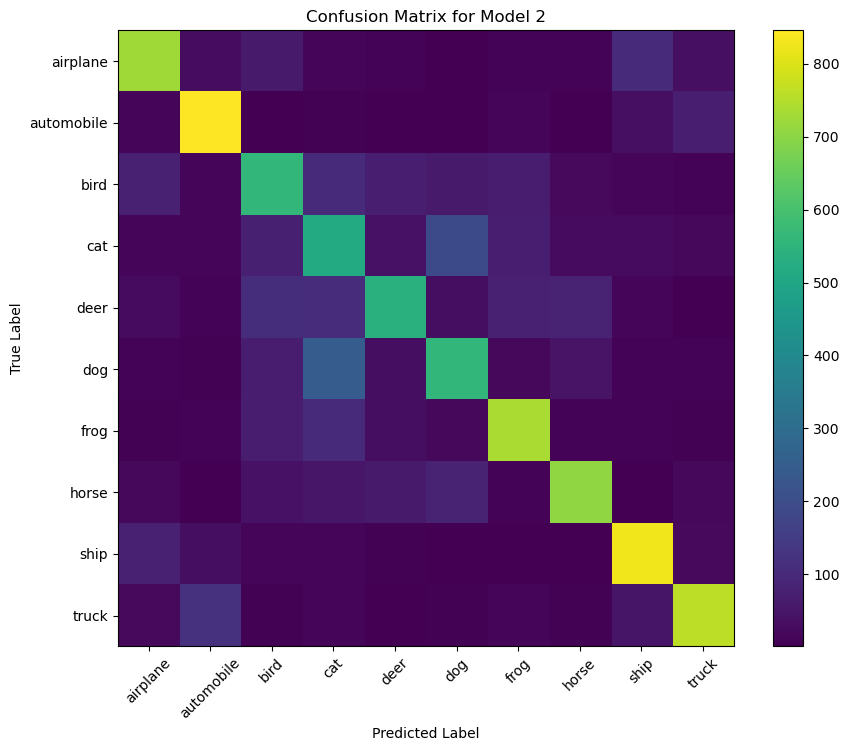

In [25]:
# Create confusion matrix
cm_2 = confusion_matrix(y_test_labels_2, y_pred_2)

plt.figure(figsize = (10, 8))
plt.imshow(cm_2)
plt.title("Confusion Matrix for Model 2")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(10), class_names, rotation = 45)
plt.yticks(range(10), class_names)
plt.colorbar()
plt.show()

In [26]:
# Compare test results for both CNN models
results = pd.DataFrame({
    "Model": ["CNN Model 1", "CNN Model 2"],
    "Test Loss": [test_loss_1, test_loss_2],
    "Test Accuracy": [test_accuracy_1, test_accuracy_2]
})

results

,Model,Test Loss,Test Accuracy
0,CNN Model 1,0.968553,0.6814
1,CNN Model 2,0.920977,0.6781


## Comparison of CNN Model 1 and CNN Model 2

The above table compares the test loss and test accuracy for both CNN models. CNN Model 1 achieved a test accuracy of about 67.8%, while CNN Model 2 achieved a test accuracy of about 67.4%. This means both models performed at almost the same level on the test set.

CNN Model 2 had a slightly lower test loss than CNN Model 1, but CNN Model 1 had a slightly higher test accuracy. Since the difference between the two models is small, there was no major improvement from adding the third convolutional layer and dropout.

Both models were able to learn useful visual patterns from the CIFAR 10 images. CNN Model 1 was simpler and performed slightly better in accuracy, while CNN Model 2 was more regularized because it included dropout.

## Sample Predictions

The sample predictions show how CNN Model 1 classified individual images from the test set. Each image displays the actual class label and the predicted class label.

Most of the examples shown were classified correctly, such as cat, ship, airplane, automobile, frog, and truck. However, there was also an incorrect prediction where an actual frog was predicted as a deer. This shows that even though the model learned useful visual patterns, it can still confuse classes when the images are small, blurry, or have similar shapes and colors.

Overall, this section gives a more visual understanding of the model's performance. The CNN was able to correctly classify many images, but it still made mistakes on some examples, which is consistent with the classification report and confusion matrix.

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


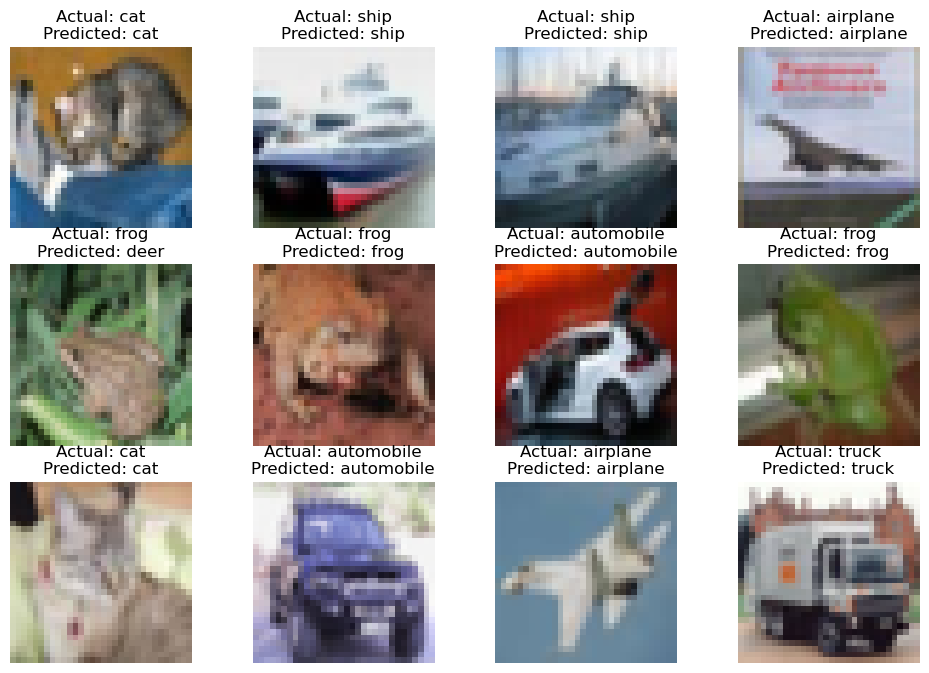

In [27]:
y_pred_prob_1 = cnn_model_1.predict(X_test)
y_pred_1 = np.argmax(y_pred_prob_1, axis = 1)

plt.figure(figsize = (12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i])
    
    actual_label = class_names[y_test_labels[i]]
    predicted_label = class_names[y_pred_1[i]]
    
    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")
    plt.axis("off")

plt.show()

## Final Analysis and Conclusion

The goal of this project was to build a convolutional neural network that could classify CIFAR 10 images into 10 different object categories. The dataset contained small 32 by 32 color images, and each image belonged to one class. This made the project a supervised multi class classification problem.

Two CNN models were created and compared. CNN Model 1 was a basic CNN with two convolutional layers, two pooling layers, a flatten layer, one dense hidden layer, and one output layer. CNN Model 2 added a third convolutional layer and a dropout layer to see if a slightly deeper and more regularized model would improve performance.

CNN Model 1 achieved a test accuracy of about 67.8%, while CNN Model 2 achieved a test accuracy of about 67.4%. The results were very close, so the extra convolutional layer and dropout in Model 2 did not lead to a major improvement in test accuracy. However, Model 2 had a slightly lower test loss, which suggests that it may have made slightly better probability based predictions even though its final accuracy was a little lower.

The accuracy and loss graphs showed that both models learned from the image data over time. Model 1 had higher training accuracy, but the validation accuracy started to level off near the later epochs, which suggested possible overfitting. Model 2 had lower training accuracy, but that is expected because dropout randomly ignores some neurons during training. The validation accuracy and validation loss for Model 2 improved steadily, which suggests that dropout helped the model generalize more smoothly.

Both models performed better on classes such as ship, truck, automobile, frog, and horse. They struggled more with visually similar animal classes such as cat, dog, bird, and deer. This makes sense because CIFAR 10 images are small and sometimes blurry, so classes with similar shapes, colors, and textures can be harder for the CNN to separate.

Overall, both CNN models were able to learn useful visual patterns from the CIFAR 10 images. CNN Model 1 was simpler and had slightly better test accuracy, while CNN Model 2 was more regularized and showed steadier validation behavior. If this project were expanded, I would try using data augmentation or training for more epochs with early stopping to see if the model could improve without overfitting.